# S3_permutation_r2 — LOWESS R² Permutation Test

Runs the same permutation test framework as S3, but for **LOWESS R²**:
fit a local regression (LOWESS) to (x, y), compute R² = 1 − SS_res/SS_tot.

LOWESS R² captures nonlinear explained variance — complementary to:
- Pearson/Spearman (linear/monotone)
- dcor/η² (general dependence)
- MINE (mutual information)

| Mode | Cases | Est. time | Use case |
|------|-------|-----------|----------|
| `quick` | ~1,000 | ~1 h | Sanity check |
| `medium` | ~5,000 | ~5 h | Solid comparison |
| `large` | ~10,000 | ~10 h | Higher confidence |
| `full` | 114,176 | ~115 h | Complete analysis |

*Times estimated at ~3.5s/case (LOWESS is faster than MINE).*

**Environment:** pip39 or base (statsmodels)

In [1]:
# ============================================================
# CONFIG
# ============================================================

SUBSET_MODE = 'medium'

# LOWESS parameters
LOWESS_FRAC = 0.3       # fraction of data for local fit (0.3 = more local detail)
LOWESS_IT = 3           # robustifying iterations

N_PERM = 500
CHECKPOINT_EVERY = 500
SEED_BASE = 300_000_000
RESUME = True

print(f'Subset mode: {SUBSET_MODE}')
print(f'LOWESS frac={LOWESS_FRAC}, it={LOWESS_IT}')

Subset mode: medium
LOWESS frac=0.3, it=3


In [2]:
from __future__ import annotations

import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from statsmodels.nonparametric.smoothers_lowess import lowess

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(it, **kw):
        return it

warnings.filterwarnings('ignore')

DATA_DIR = Path('generated_scatterplot_data')
S3_DIR   = DATA_DIR / 'full' / 'S3'
OUT_DIR  = DATA_DIR / 'full' / 'S3_r2' / f'S3_r2_{SUBSET_MODE}'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Output → {OUT_DIR}')

Output → generated_scatterplot_data/full/S3_r2/S3_r2_medium


/Users/mimi/miniconda3/envs/pip39/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print('Loading scatter_points.npz ...')
pts = np.load(DATA_DIR / 'scatter_points.npz')
x_full = pts['x']
y_full = pts['y']
n_full, n_points = x_full.shape

cases = pd.read_csv(DATA_DIR / 'cases.csv', low_memory=False)
is_null_func = cases['family_id'] == 'Null'
is_const_spread = cases['spread_pattern'] == 'constant'
cases['category'] = 'mean+variance'
cases.loc[is_null_func & is_const_spread, 'category'] = 'true_null'
cases.loc[~is_null_func & is_const_spread, 'category'] = 'mean_only'
cases.loc[is_null_func & ~is_const_spread, 'category'] = 'variance_only'

# --- Build subset indices (same logic as S3_permutation_mine) ---
if SUBSET_MODE == 'full':
    subset_idx = np.arange(n_full)
else:
    rng_sub = np.random.default_rng(42)
    rare_mask = cases['category'].isin(['true_null', 'variance_only'])
    rare_idx = np.where(rare_mask)[0]

    mo_idx = np.where(cases['category'] == 'mean_only')[0]
    mv_idx = np.where(cases['category'] == 'mean+variance')[0]

    if SUBSET_MODE == 'quick':
        n_mo, n_mv = 300, 572
    elif SUBSET_MODE == 'medium':
        n_mo, n_mv = 1500, 3372
    elif SUBSET_MODE == 'large':
        n_mo, n_mv = 2500, 7372
    elif SUBSET_MODE == 'xlarge':
        n_mo, n_mv = 5000, 14872
    else:
        raise ValueError(f'Unknown SUBSET_MODE: {SUBSET_MODE}')

    mo_sample = rng_sub.choice(mo_idx, size=min(n_mo, len(mo_idx)), replace=False)
    mv_sample = rng_sub.choice(mv_idx, size=min(n_mv, len(mv_idx)), replace=False)
    subset_idx = np.sort(np.concatenate([rare_idx, mo_sample, mv_sample]))

x_all = x_full[subset_idx]
y_all = y_full[subset_idx]
case_ids = subset_idx
n_cases = len(subset_idx)
cases_sub = cases.iloc[subset_idx].reset_index(drop=True)

print(f'Loaded: {n_full:,} total cases × {n_points} points')
print(f'Subset: {n_cases:,} cases ({SUBSET_MODE} mode)')
print(f'  Estimated time: ~{n_cases * 3.5 / 3600:.1f} hours')
print()
print('Subset composition:')
print(cases_sub['category'].value_counts().to_string())

Loading scatter_points.npz ...
Loaded: 114,176 total cases × 500 points
Subset: 5,000 cases (medium mode)
  Estimated time: ~4.9 hours

Subset composition:
category
mean+variance    3372
mean_only        1500
variance_only      96
true_null          32


## Phase 1 — Compute LOWESS R² Observed + Null

For each case:
1. Fit LOWESS on (x, y) → ŷ → R² = 1 − SS_res/SS_tot
2. For each of 500 permutations of y, repeat → null distribution

In [4]:
def compute_lowess_r2(x, y, frac=LOWESS_FRAC, it=LOWESS_IT):
    """Fit LOWESS and return R²."""
    result = lowess(y, x, frac=frac, it=it, return_sorted=True)
    x_sorted = result[:, 0]
    y_hat_sorted = result[:, 1]
    # Map predictions back to original order
    sort_idx = np.argsort(x)
    y_hat = np.empty_like(y)
    y_hat[sort_idx] = y_hat_sorted
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    if ss_tot < 1e-15:
        return 0.0
    return float(1.0 - ss_res / ss_tot)


def generate_perms(n, n_perm, seed):
    rng = np.random.default_rng(seed)
    return np.array([rng.permutation(n) for _ in range(n_perm)])


# Test
t_test = time.time()
r2_test = compute_lowess_r2(x_all[0], y_all[0])
dt = time.time() - t_test
print(f'Test case 0: LOWESS R²={r2_test:.4f} ({dt*1000:.0f} ms/fit)')
print(f'Estimated per case (501 fits): ~{dt * 501:.1f}s')

Test case 0: LOWESS R²=0.0537 (72 ms/fit)
Estimated per case (501 fits): ~36.3s


In [5]:
def save_checkpoint(idx, r2_obs, r2_null):
    path = OUT_DIR / f'_r2_ckpt_{SUBSET_MODE}_{idx:06d}.npz'
    np.savez_compressed(
        path,
        completed=idx,
        case_ids=case_ids[:idx],
        r2_obs=r2_obs[:idx],
        r2_null=r2_null[:idx],
    )
    print(f'  Checkpoint saved: {path.name} ({idx:,}/{n_cases:,})')


def find_latest_checkpoint():
    pattern = f'_r2_ckpt_{SUBSET_MODE}_*.npz'
    ckpts = sorted(OUT_DIR.glob(pattern))
    if not ckpts:
        return 0, None
    latest = ckpts[-1]
    data = np.load(latest)
    idx = int(data['completed'])
    print(f'  Resuming from: {latest.name} ({idx:,}/{n_cases:,} completed)')
    return idx, data


print('Checkpoint utilities ready')

Checkpoint utilities ready


In [6]:
r2_obs  = np.empty(n_cases, dtype=np.float64)
r2_null = np.empty((n_cases, N_PERM), dtype=np.float32)

start_idx = 0
if RESUME:
    start_idx, ckpt_data = find_latest_checkpoint()
    if ckpt_data is not None:
        r2_obs[:start_idx]  = ckpt_data['r2_obs']
        r2_null[:start_idx] = ckpt_data['r2_null']

remaining = n_cases - start_idx
print(f'Starting from case {start_idx:,}, {remaining:,} remaining')
print(f'Estimated time: ~{remaining * 3.5 / 3600:.1f} hours')

t0 = time.time()
for i in tqdm(range(start_idx, n_cases), desc='LOWESS R² permutation',
              initial=start_idx, total=n_cases):
    x = x_all[i]
    y = y_all[i]

    r2_obs[i] = compute_lowess_r2(x, y)

    perms = generate_perms(n_points, N_PERM, SEED_BASE + i)
    for k in range(N_PERM):
        r2_null[i, k] = compute_lowess_r2(x, y[perms[k]])

    if (i + 1) % CHECKPOINT_EVERY == 0:
        elapsed = time.time() - t0
        done = i + 1 - start_idx
        rate = done / elapsed
        eta_h = (n_cases - i - 1) / rate / 3600 if rate > 0 else 0
        print(f'  [{i+1:>7,}/{n_cases:,}]  {rate:.2f} cases/s  ETA {eta_h:.1f} h')
        save_checkpoint(i + 1, r2_obs, r2_null)

elapsed_total = (time.time() - t0) / 3600
print(f'\nPhase 1 done in {elapsed_total:.1f} hours')
save_checkpoint(n_cases, r2_obs, r2_null)

Starting from case 0, 5,000 remaining
Estimated time: ~4.9 hours


LOWESS R² permutation:  10%|█         | 500/5000 [1:17:26<8:32:50,  6.84s/it]   

  [    500/5,000]  0.11 cases/s  ETA 11.6 h
  Checkpoint saved: _r2_ckpt_medium_000500.npz (500/5,000)


LOWESS R² permutation:  20%|██        | 1000/5000 [2:14:26<8:38:25,  7.78s/it]

  [  1,000/5,000]  0.12 cases/s  ETA 9.0 h
  Checkpoint saved: _r2_ckpt_medium_001000.npz (1,000/5,000)


...

LOWESS R² permutation: 100%|█████████▉| 4999/5000 [12:24:30<00:09,  9.08s/it]  

  [  5,000/5,000]  0.11 cases/s  ETA 0.0 h


LOWESS R² permutation: 100%|██████████| 5000/5000 [12:24:40<00:00,  8.94s/it]

  Checkpoint saved: _r2_ckpt_medium_005000.npz (5,000/5,000)

Phase 1 done in 12.4 hours


  Checkpoint saved: _r2_ckpt_medium_005000.npz (5,000/5,000)


In [7]:
out_name = f'_r2_perm_{SUBSET_MODE}.npz'
np.savez_compressed(
    OUT_DIR / out_name,
    case_ids=case_ids,
    r2_obs=r2_obs,
    r2_null=r2_null,
)
print(f'Saved final arrays → {OUT_DIR}/{out_name}')
print(f'  {n_cases:,} cases × {N_PERM} permutations')

for ckpt in OUT_DIR.glob(f'_r2_ckpt_{SUBSET_MODE}_*.npz'):
    ckpt.unlink()
    print(f'  Removed {ckpt.name}')
print('Checkpoints cleaned up')

Saved final arrays → generated_scatterplot_data/full/S3_r2/S3_r2_medium/_r2_perm_medium.npz
  5,000 cases × 500 permutations
  Removed _r2_ckpt_medium_001000.npz
  Removed _r2_ckpt_medium_003000.npz
  Removed _r2_ckpt_medium_003500.npz
  Removed _r2_ckpt_medium_001500.npz
  Removed _r2_ckpt_medium_005000.npz
  Removed _r2_ckpt_medium_004500.npz
  Removed _r2_ckpt_medium_002000.npz
  Removed _r2_ckpt_medium_002500.npz
  Removed _r2_ckpt_medium_000500.npz
  Removed _r2_ckpt_medium_004000.npz
Checkpoints cleaned up


## Phase 2 — Z-scores + Joint Test

In [8]:
def compute_z(obs, null):
    null_f64 = null.astype(np.float64)
    med = np.median(null_f64, axis=1)
    q75 = np.percentile(null_f64, 75, axis=1)
    q25 = np.percentile(null_f64, 25, axis=1)
    iqr = q75 - q25
    tiny = iqr < 1e-12
    iqr[tiny] = np.std(null_f64[tiny], axis=1) * 1.35
    still_tiny = iqr < 1e-12
    iqr[still_tiny] = 1.0
    z_obs = (obs - med) / iqr
    z_null = (null_f64 - med[:, None]) / iqr[:, None]
    return z_obs, z_null, med, iqr


z_r2_obs, z_r2_null, r2_null_med, r2_null_iqr = compute_z(r2_obs, r2_null)
print(f'LOWESS R²: Z mean={z_r2_obs.mean():.2f}, Z std={z_r2_obs.std():.2f}')

# R²-only p-value
p_r2 = (np.sum(r2_null.astype(np.float64) >= r2_obs[:, None], axis=1) + 1) / (N_PERM + 1)
clf_r2 = np.where(p_r2 <= 0.05, 'detectable',
         np.where(p_r2 >= 0.10, 'not_detectable', 'uncertain'))

print(f'\nR²-only classification:')
print(pd.Series(clf_r2).value_counts().to_string())

LOWESS R²: Z mean=11332.97, Z std=295212.18

R²-only classification:
detectable        4647
not_detectable     318
uncertain           35


In [9]:
# Combined joint test: S3's 4 metrics + LOWESS R²
print('Loading S3 null arrays for combined test...')
p1 = np.load(S3_DIR / '_perm_phase1.npz')
p2 = np.load(S3_DIR / '_perm_phase2.npz')

s3_metrics = {
    'pearson':  (p1['pearson_obs'][subset_idx],  p1['pearson_null'][subset_idx]),
    'spearman': (p1['spearman_obs'][subset_idx], p1['spearman_null'][subset_idx]),
    'eta2':     (p1['eta2_obs'][subset_idx],     p1['eta2_null'][subset_idx]),
    'dcor':     (p2['dcor_obs'][subset_idx],     p2['dcor_null'][subset_idx]),
}

s3_z = {}
s3_z_null = {}
for name, (obs, null) in s3_metrics.items():
    z_o, z_n, _, _ = compute_z(obs, null)
    s3_z[name] = z_o
    s3_z_null[name] = z_n

# S3 original classification (subset)
s3_df = pd.read_parquet(S3_DIR / 'permutation_test.parquet')
s3_clf_sub = s3_df['classification'].values[subset_idx]

# Stack: S3 (4) + LOWESS R²
all_names = ['pearson', 'spearman', 'dcor', 'eta2', 'lowess_r2']
all_z_obs = np.stack([s3_z['pearson'], s3_z['spearman'], s3_z['dcor'],
                      s3_z['eta2'], z_r2_obs])
all_z_null = np.stack([s3_z_null['pearson'], s3_z_null['spearman'],
                       s3_z_null['dcor'], s3_z_null['eta2'], z_r2_null])

T_obs_combined = all_z_obs.max(axis=0)
T_null_combined = all_z_null.max(axis=0)

p_combined = (np.sum(T_null_combined >= T_obs_combined[:, None], axis=1) + 1) / (N_PERM + 1)
clf_combined = np.where(p_combined <= 0.05, 'detectable',
               np.where(p_combined >= 0.10, 'not_detectable', 'uncertain'))

driver_idx_c = all_z_obs.argmax(axis=0)
driver_combined = np.array([all_names[d] for d in driver_idx_c])

print(f'Combined joint test ({all_names}):')
print(pd.Series(clf_combined).value_counts().to_string())

Loading S3 null arrays for combined test...
Combined joint test (['pearson', 'spearman', 'dcor', 'eta2', 'lowess_r2']):
detectable        4906
not_detectable      77
uncertain           17


## Phase 3 — Results & Comparison

In [10]:
results = pd.DataFrame({
    'case_id': case_ids,
    'category': cases_sub['category'].values,
    'family_id': cases_sub['family_id'].values,
    'snr': cases_sub['snr'].values,
    'r2_obs': r2_obs,
    'r2_null_median': r2_null_med,
    'r2_null_iqr': r2_null_iqr,
    'z_r2': z_r2_obs,
    'p_r2': p_r2,
    'clf_r2': clf_r2,
    'T_combined': T_obs_combined,
    'p_combined': p_combined,
    'clf_combined': clf_combined,
    'driver_combined': driver_combined,
})

out_pq = OUT_DIR / f'r2_permutation_test_{SUBSET_MODE}.parquet'
results.to_parquet(out_pq, index=False)
print(f'Saved → {out_pq}')
print(f'Shape: {results.shape}')

Saved → generated_scatterplot_data/full/S3_r2/S3_r2_medium/r2_permutation_test_medium.parquet
Shape: (5000, 14)


In [11]:
import matplotlib.pyplot as plt
%matplotlib inline

cats = ['true_null', 'mean_only', 'variance_only', 'mean+variance']
cat_arr = cases_sub['category'].values

print(f'=== Detection Rate Comparison ({SUBSET_MODE} mode, n={n_cases:,}) ===')
print(f'{"Category":>20s}  {"S3 (4 metrics)":>15s}  {"R²-only":>12s}  {"Combined":>12s}')
print('-' * 65)
for cat in cats:
    mask = cat_arr == cat
    n_cat = mask.sum()
    s3_rate = (s3_clf_sub[mask] == 'detectable').mean()
    r2_rate = (clf_r2[mask] == 'detectable').mean()
    comb_rate = (clf_combined[mask] == 'detectable').mean()
    print(f'{cat:>20s}  {s3_rate:>14.1%}  {r2_rate:>11.1%}  {comb_rate:>11.1%}  (n={n_cat})')

=== Detection Rate Comparison (medium mode, n=5,000) ===
            Category   S3 (4 metrics)       R²-only      Combined
-----------------------------------------------------------------
           true_null           12.5%         6.2%         9.4%  (n=32)
           mean_only           96.6%        95.5%        97.0%  (n=1500)
       variance_only           96.9%         3.1%        95.8%  (n=96)
       mean+variance           99.8%        95.2%        99.5%  (n=3372)


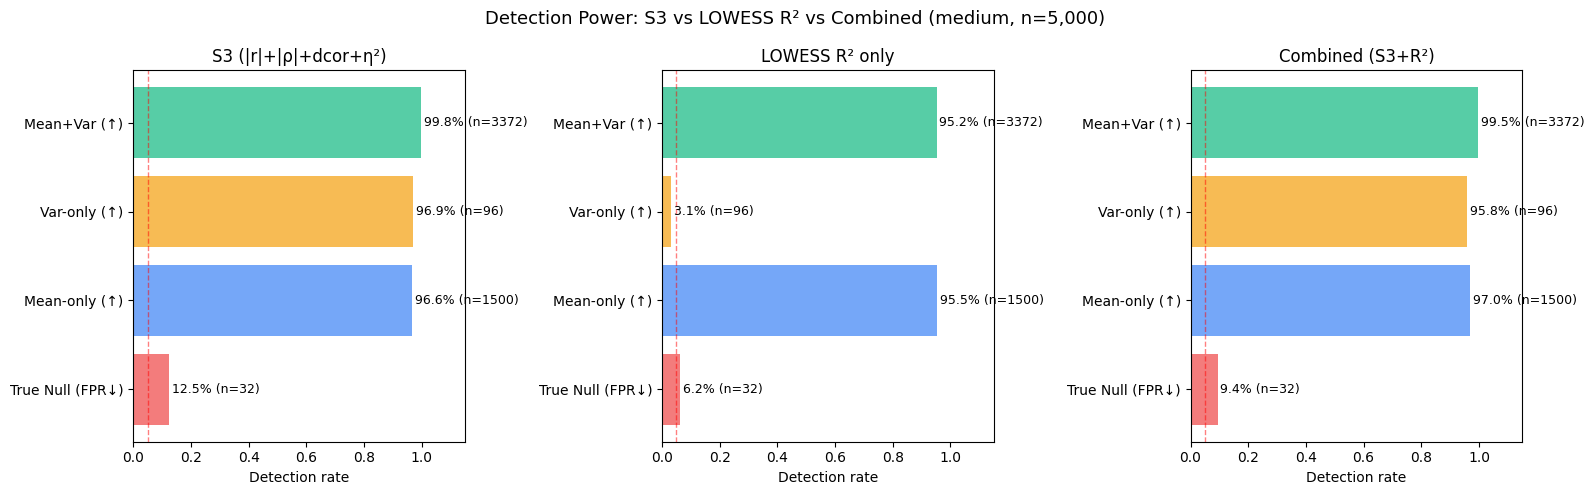

In [12]:
cat_labels = ['True Null (FPR↓)', 'Mean-only (↑)', 'Var-only (↑)', 'Mean+Var (↑)']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (test_name, clf_arr) in zip(axes,
        [('S3 (|r|+|ρ|+dcor+η²)', s3_clf_sub),
         ('LOWESS R² only', clf_r2),
         ('Combined (S3+R²)', clf_combined)]):
    rates = []
    for cat in cats:
        mask = cat_arr == cat
        rates.append((clf_arr[mask] == 'detectable').mean())
    colors = ['#ef4444', '#3b82f6', '#f59e0b', '#10b981']
    ax.barh(range(4), rates, color=colors, alpha=0.7)
    ax.set_yticks(range(4))
    ax.set_yticklabels(cat_labels)
    ax.set_xlabel('Detection rate')
    ax.set_title(test_name)
    ax.set_xlim(0, 1.15)
    ax.axvline(0.05, color='red', ls='--', lw=1, alpha=0.5)
    for i, r in enumerate(rates):
        n_cat = (cat_arr == cats[i]).sum()
        ax.text(r + 0.01, i, f'{r:.1%} (n={n_cat})', va='center', fontsize=9)

plt.suptitle(f'Detection Power: S3 vs LOWESS R² vs Combined ({SUBSET_MODE}, n={n_cases:,})', fontsize=13)
plt.tight_layout()
fig.savefig(OUT_DIR / f'r2_vs_s3_{SUBSET_MODE}.png', bbox_inches='tight')
plt.show()

In [13]:
det_mask = clf_combined == 'detectable'
print(f'Combined test: driver metric distribution (among {det_mask.sum():,} detectable cases):')
print(pd.Series(driver_combined[det_mask]).value_counts().to_string())
print()
print('→ If lowess_r2 frequently drives detection, it captures signals the original 4 miss.')

Combined test: driver metric distribution (among 4,906 detectable cases):
lowess_r2    3051
eta2         1111
dcor          743
pearson         1

→ If lowess_r2 frequently drives detection, it captures signals the original 4 miss.


In [14]:
tn_mask = cat_arr == 'true_null'
print(f'LOWESS R² under True Null (n={tn_mask.sum()}):')
print(f'  Obs mean:     {r2_obs[tn_mask].mean():.4f}')
print(f'  Null median:  {r2_null_med[tn_mask].mean():.4f}')
print(f'  Null IQR:     {r2_null_iqr[tn_mask].mean():.4f}')
print(f'  Z mean:       {z_r2_obs[tn_mask].mean():.2f}')
print(f'  FPR:          {(p_r2[tn_mask] <= 0.05).mean():.1%}')
print()
print('Note: LOWESS R² has positive bias under null (overfitting to noise).')
print('The permutation test accounts for this.')

LOWESS R² under True Null (n=32):
  Obs mean:     0.0008
  Null median:  -0.0018
  Null IQR:     0.0091
  Z mean:       0.23
  FPR:          6.2%

Note: LOWESS R² has positive bias under null (overfitting to noise).
The permutation test accounts for this.


In [15]:
# Detection rate by family (R² only vs S3)
family_arr = cases_sub['family_id'].values
families = sorted(cases_sub['family_id'].unique())

print(f'\n{"Family":>8s}  {"n":>5s}  {"S3":>6s}  {"R²":>6s}  {"Combined":>9s}  {"R² drives":>10s}')
print('-' * 55)
for fam in families:
    mask = family_arr == fam
    n_f = mask.sum()
    if n_f < 5:
        continue
    s3_r = (s3_clf_sub[mask] == 'detectable').mean()
    r2_r = (clf_r2[mask] == 'detectable').mean()
    co_r = (clf_combined[mask] == 'detectable').mean()
    r2_drives = (driver_combined[mask & det_mask] == 'lowess_r2').sum() if (mask & det_mask).sum() > 0 else 0
    print(f'{fam:>8s}  {n_f:>5d}  {s3_r:>5.1%}  {r2_r:>5.1%}  {co_r:>8.1%}  {r2_drives:>10d}')


  Family      n      S3      R²   Combined   R² drives
-------------------------------------------------------
     F01     94  100.0%  100.0%    100.0%          67
     F02     87  100.0%  100.0%    100.0%          53
     F03     65  100.0%  100.0%    100.0%          40
     F04     67  98.5%  98.5%     98.5%          43
     F05     66  100.0%  97.0%    100.0%          45
     F06     63  100.0%  98.4%    100.0%          44
     F07    167  96.4%  89.8%     96.4%         106
     F08    158  96.2%  91.8%     96.2%          99
     F09     81  100.0%  98.8%    100.0%          61
     F10     89  100.0%  96.6%    100.0%          52
     F11    205  99.0%  96.6%     99.0%         139
     F12    175  99.4%  96.6%     99.4%         120
     F13    263  99.6%  99.6%     99.6%         177
     F14    231  99.6%  99.1%    100.0%         144
     F15    806  98.4%  94.3%     98.1%         435
     F16    720  98.6%  94.0%     98.1%         381
     F17    358  99.4%  97.8%     99.7%       

In [16]:
print('='*60)
print(f'SUMMARY ({SUBSET_MODE} mode)')
print('='*60)
print()
print(f'Cases: {n_cases:,} / {n_full:,} ({SUBSET_MODE})')
print(f'Metric: LOWESS R² (frac={LOWESS_FRAC}, it={LOWESS_IT})')
print(f'Permutations: {N_PERM}')
print()
print('Detection rates by category:')
print(f'{"":>20s}  {"S3 original":>12s}  {"R²-only":>12s}  {"Combined":>12s}')
for cat in cats:
    mask = cat_arr == cat
    s3_r = (s3_clf_sub[mask] == 'detectable').mean()
    r2_r = (clf_r2[mask] == 'detectable').mean()
    co_r = (clf_combined[mask] == 'detectable').mean()
    print(f'{cat:>20s}  {s3_r:>11.1%}  {r2_r:>11.1%}  {co_r:>11.1%}')
print()
if SUBSET_MODE != 'full':
    print(f'→ This was a {SUBSET_MODE} run. Change SUBSET_MODE to scale up.')

SUMMARY (medium mode)

Cases: 5,000 / 114,176 (medium)
Metric: LOWESS R² (frac=0.3, it=3)
Permutations: 500

Detection rates by category:
                       S3 original       R²-only      Combined
           true_null        12.5%         6.2%         9.4%
           mean_only        96.6%        95.5%        97.0%
       variance_only        96.9%         3.1%        95.8%
       mean+variance        99.8%        95.2%        99.5%

→ This was a medium run. Change SUBSET_MODE to scale up.
